In [84]:
import numpy as np
import pandas as pd
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier

In [85]:
df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\AI_Course\ModularProgramProjects\finalProject\data\sampled_data\sampled_data.csv")

In [86]:
df.sample(3)

,Efficiency,Weight_kg,Acceleration(0-100),Firth_stop_range_km,Battery_kWh,Fast_charger(kW),Towing_kg,Cargo_volume,Price/Range(km),FastCharge_time_hrs,Energy_weight_ratio,Added_Range_1Stop,Range_km_level,Price_level
455,0.408602,0.667630,0.024510,0.800259,0.760369,0.809091,0.00,0.2135,0.306971,0.198677,0.784661,0.927419,2,2
1046,0.656213,0.820889,0.127107,0.521914,0.843318,0.439394,0.60,0.3155,0.189251,0.399784,0.746137,0.327295,2,2
206,0.344086,0.648362,0.215686,0.656291,0.701382,0.412121,0.25,0.2150,0.095174,0.364315,0.729745,0.479839,2,2


# Correlation with target

In [87]:
import pandas as pd

numeric_features = df.select_dtypes(include=[np.number]).drop(columns=['Range_km_level'])
target = df['Range_km_level']

# Pearson
pearson_corr = df[numeric_features.columns].corrwith(target)
# print("Pearson Correlation with Range km level\n", pearson_corr.sort_values(ascending=False))

# Spearman 
spearman_corr = df[numeric_features.columns].corrwith(target, method='spearman')
# print("\nSpearman Correlation with range km level \n", spearman_corr.sort_values(ascending=False))

#--------------------------------------------------------------------------------------------------------

numeric_features1 = df.select_dtypes(include=[np.number]).drop(columns=['Price_level'])
target1 = df['Price_level']

# Pearson
pearson_corr1 = df[numeric_features1.columns].corrwith(target1)
# print("Pearson Correlation with Range km level\n", pearson_corr1.sort_values(ascending=False))

# Spearman 
spearman_corr1 = df[numeric_features1.columns].corrwith(target1, method='spearman')
# print("\nSpearman Correlation with range km level \n", spearman_corr1.sort_values(ascending=False))

# ---------------------------------------------------------------------------------------------------

data = {
    "Range_level_Pearson": pearson_corr,
    "Range_level_Spearman" : spearman_corr,
    "Price_level_Pearson": pearson_corr1,
    "Price_level_Spearman" : spearman_corr1
}

table = pd.DataFrame(data).sort_values(by='Range_level_Pearson', ascending=False)

In [88]:
table

,Range_level_Pearson,Range_level_Spearman,Price_level_Pearson,Price_level_Spearman
Firth_stop_range_km,0.878883,0.915032,0.603611,0.616690
Battery_kWh,0.803766,0.828120,0.780328,0.801091
Energy_weight_ratio,0.787358,0.851513,0.556228,0.577400
Fast_charger(kW),0.683849,0.778251,0.612024,0.686962
Weight_kg,0.605164,0.607364,0.823137,0.858283
Price_level,0.600963,0.600283,NaN,NaN
Added_Range_1Stop,0.589277,0.616195,0.384328,0.368961
Towing_kg,0.369383,0.365680,0.399129,0.391455
Cargo_volume,0.159477,0.293549,0.269424,0.389614
Price/Range(km),0.006909,-0.014153,0.512313,0.597246


# Correlation with features

In [89]:
import plotly.express as px
import numpy as np
import pandas as pd

corr_matrix = df[numeric_features.columns].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,       
    color_continuous_scale='RdBu_r',
    origin='upper',
    labels=dict(x="Features", y="Features", color="Correlation"),
    title="Feature-to-Feature Correlation (Numeric Features)"
)
fig.update_xaxes(side="top")
fig.show()

upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Highly correlated features to drop:", to_drop)


Highly correlated features to drop: ['Battery_kWh', 'Energy_weight_ratio', 'Added_Range_1Stop']


In [90]:
df_new = df.drop(columns=['Added_Range_1Stop'])

# Feature importance with model(XGBoost)

In [91]:
x = df_new.drop(columns=['Range_km_level','Price_level'])
y = df_new[['Range_km_level','Price_level']]

In [92]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

In [93]:
xb = MultiOutputClassifier(XGBClassifier(random_state=99))
xb.fit(x,y)

Range_feat_importance = pd.Series(xb.estimators_[0].feature_importances_, index=x.columns).sort_values(ascending=False)
Price_feat_importance = pd.Series(xb.estimators_[1].feature_importances_,index=x.columns).sort_values(ascending=False)

# print("XGboost Range Feature Importance:\n", Range_feat_importance) 
# print("XGBoost Price feature importance:\n ", Price_feat_importance)

data = {
    'Range Level':Range_feat_importance,
    'Price Level': Price_feat_importance
}
jadval = pd.DataFrame(data).sort_values(by='Range Level', ascending=False)
jadval

,Range Level,Price Level
Firth_stop_range_km,0.556927,0.055179
Energy_weight_ratio,0.107028,0.036287
FastCharge_time_hrs,0.090446,0.016691
Fast_charger(kW),0.081228,0.029797
Battery_kWh,0.063240,0.056879
Weight_kg,0.025484,0.527117
Efficiency,0.021060,0.025331
Towing_kg,0.020903,0.132332
Acceleration(0-100),0.014410,0.036934
Cargo_volume,0.011053,0.018617


# Shap

Local shap


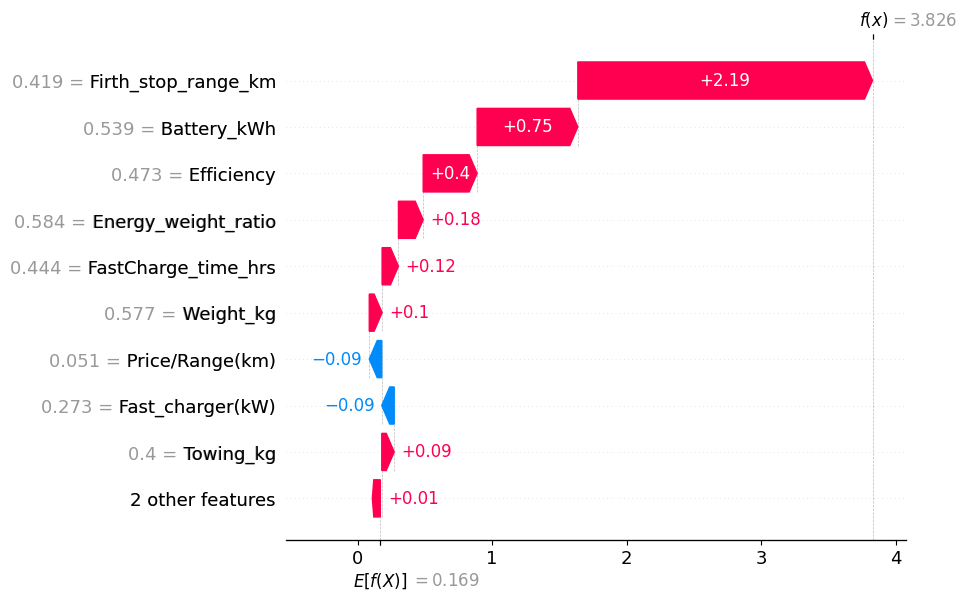

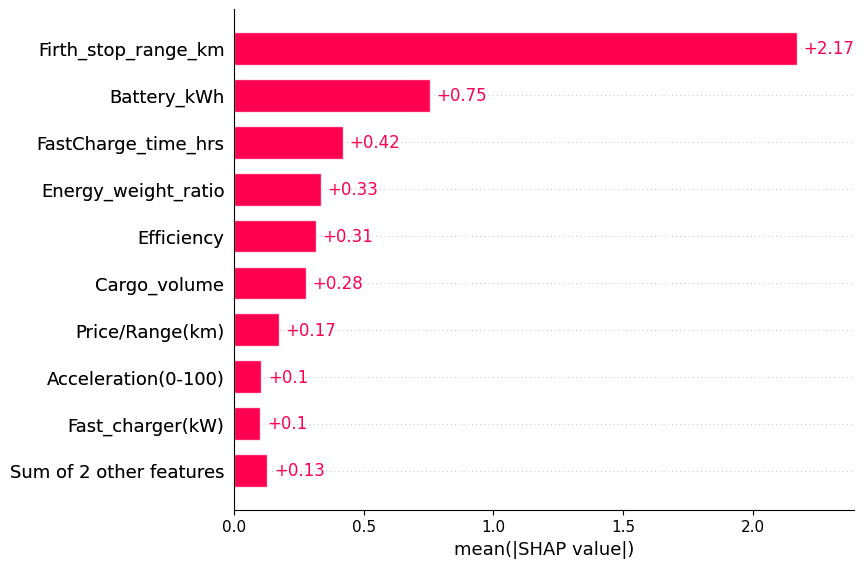

Global Shap


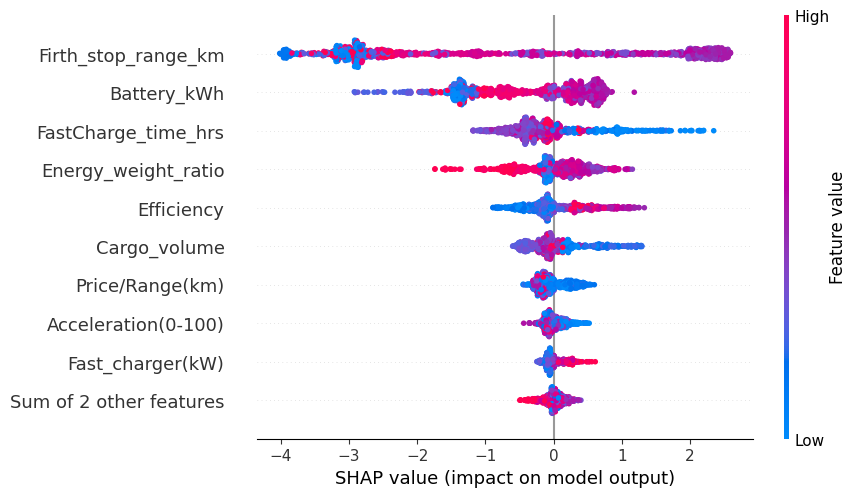

In [106]:
import shap
from xgboost import XGBClassifier

x = df_new.drop(columns=['Range_km_level','Price_level'])
y = df_new['Range_km_level']

model = XGBClassifier()
model.fit(x,y)


explainer = shap.Explainer(model)

shap_values = explainer(x)

print("Local shap")
shap.plots.waterfall(shap_values[0, :, 1]) 
shap.plots.bar(shap_values[:, :, 1])

print("Global Shap")
# shap.plots.waterfall(shap_values[:, :, 1])
# shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# model checking after Feature analaysis

In [ ]:
x = df_new.drop(columns=['Range_km_level','Price_level'])
y = df_new[['Range_km_level','Price_level']]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.19, random_state=99)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    "SVM (SVC)": MultiOutputClassifier(SVC(random_state=42)),
    "Gradient Boosting": MultiOutputClassifier(GradientBoostingClassifier(random_state=42)),
    "XGBoost": MultiOutputClassifier(XGBClassifier(random_state=42,eval_metric='logloss')),
}

results = []
for name, model in models.items():
    try:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        
        acc_price = accuracy_score(y_test.iloc[:, 0], y_pred[:, 0])
        acc_range = accuracy_score(y_test.iloc[:, 1], y_pred[:, 1])
        avg_acc = (acc_price + acc_range) / 2
        
        results.append({
            "Model": name,
            "Price Accuracy (%)": round(acc_price * 100, 2),
            "Range Accuracy (%)": round(acc_range * 100, 2),
            "Average": round(avg_acc * 100, 2)
        })
    except Exception as e:
        print(f"Errors: {e}")

results_df = pd.DataFrame(results).sort_values(by='Average',ascending=False)
print(results_df.to_markdown(index=False))

| Model               |   Price Accuracy (%) |   Range Accuracy (%) |   Average |
|:--------------------|---------------------:|---------------------:|----------:|
| XGBoost             |                 97.2 |                 94   |      95.6 |
| Gradient Boosting   |                 96   |                 92.4 |      94.2 |
| Random Forest       |                 96.4 |                 90.8 |      93.6 |
| Extra Trees         |                 96   |                 90.4 |      93.2 |
| SVM (SVC)           |                 95.6 |                 84   |      89.8 |
| Decision Tree       |                 92.8 |                 84.8 |      88.8 |
| KNN                 |                 93.2 |                 84   |      88.6 |
| Logistic Regression |                 91.2 |                 80.8 |      86   |


In [ ]:
import os
path = r"C:\Users\bunyo\OneDrive\Desktop\AI_Course\ModularProgramProjects\finalProject\model\table"
full_path = os.path.join(path, "final_jadval.csv")
results_df.to_csv(full_path, index=False)